In [12]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [13]:
import chardet
with open('Order Book 2024 copied.csv', 'rb') as f:
    raw = f.read(500000) 

det = chardet.detect(raw)
print(det) 
df = pd.read_csv("Orderbook from May'23 to May'25-R1.csv", encoding=det['encoding'])

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [14]:
df['ORDER DATE'] = pd.to_datetime(df['ORDER DATE'])
df = df.sort_values('ORDER DATE')

In [15]:
df['Month'] = df['ORDER DATE'].dt.month
df['Year'] = df['ORDER DATE'].dt.year
#df['dayofweek'] = df['ORDER DATE'].dt.dayofweek
df['quarter'] = df['ORDER DATE'].dt.quarter

In [16]:
# Filter to include data only up to March 2025
df = df[(df['Year'] < 2025) | ((df['Year'] == 2025) & (df['Month'] <= 3))]

In [17]:
df.shape

(7569, 38)

C:\Users\Sonam Gupta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Order Qty in MT', ylabel='Count'>

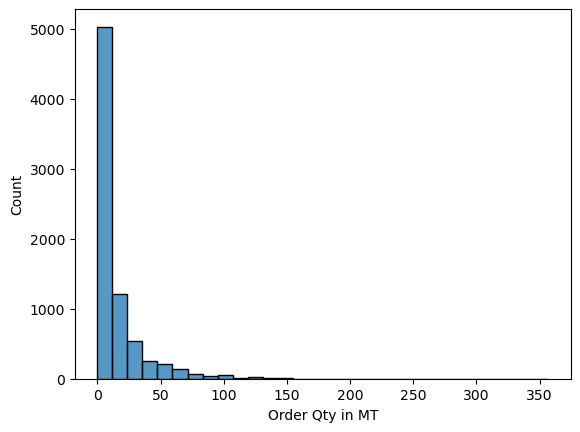

In [18]:
import seaborn as sns
sns.histplot(df['Order Qty in MT'], bins=30)

In [19]:
#df['log_qty'] = np.log1p(df['Order Qty in MT'])

In [20]:
#sns.histplot(df['log_qty'], bins=30)

In [21]:
monthly_growth = df.groupby(pd.Grouper(key='ORDER DATE', freq='MS'))['Order Qty in MT'].sum().reset_index()

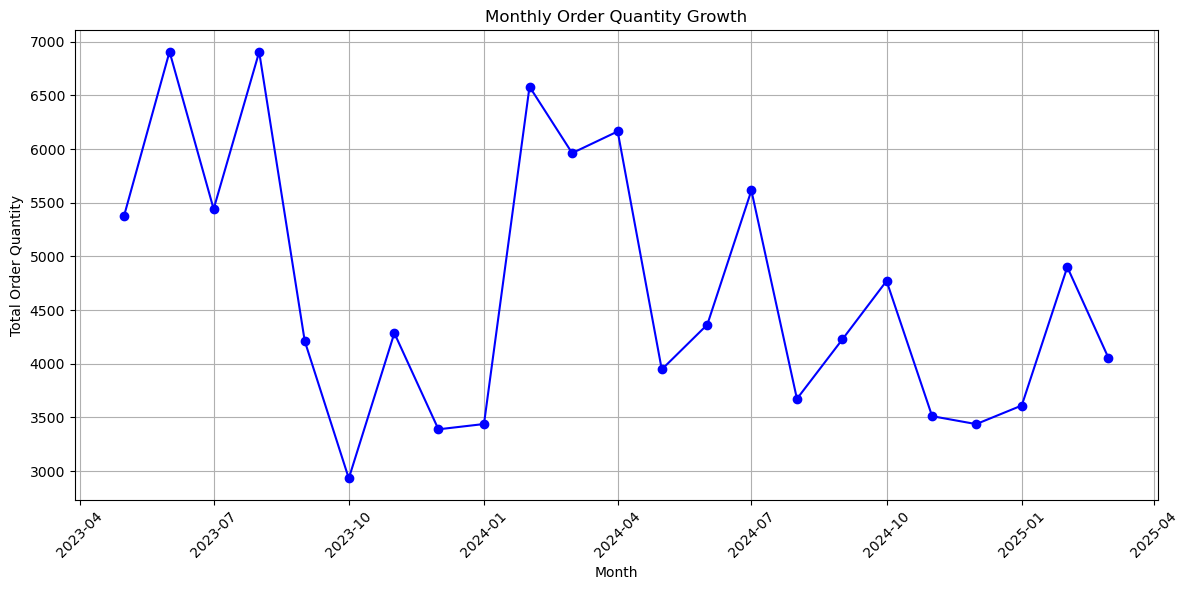

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_growth['ORDER DATE'], monthly_growth['Order Qty in MT'], marker='o', color='blue')
plt.title("Monthly Order Quantity Growth")
plt.xlabel("Month")
plt.ylabel("Total Order Quantity")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sonam Gupta\AppData\Local\Temp\ipykernel_10656\4207524108.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Sonam Gupta\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


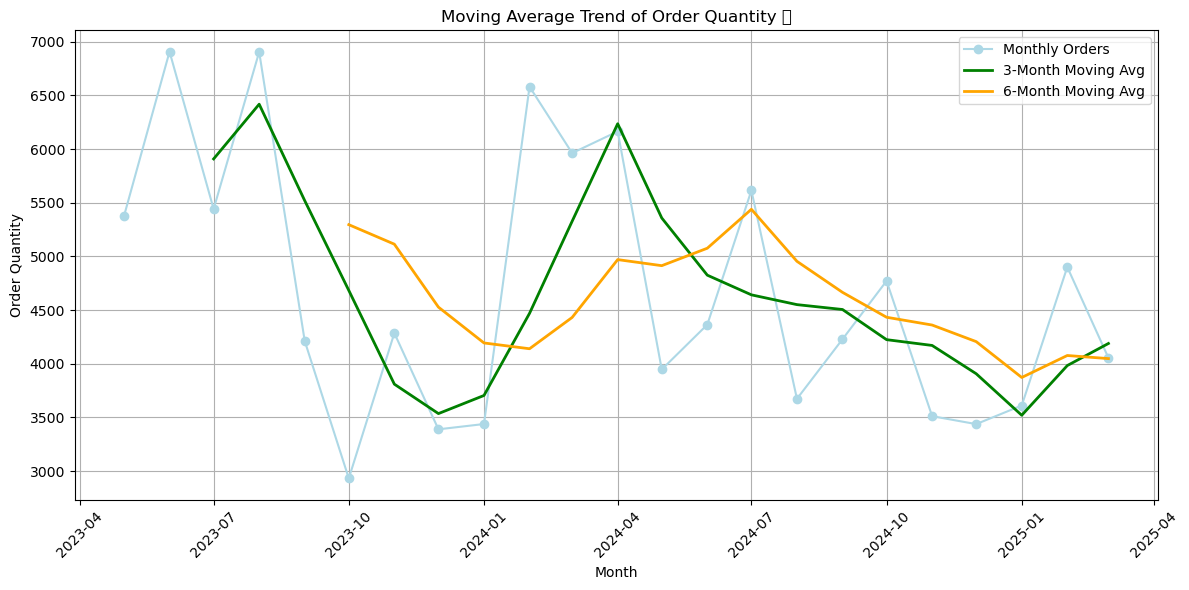

In [23]:
monthly_data = df.groupby(pd.Grouper(key='ORDER DATE', freq='MS'))['Order Qty in MT'].sum().reset_index()

# Calculate the 3-month and 6-month moving averages
monthly_data['MA_3'] = monthly_data['Order Qty in MT'].rolling(window=3).mean()
monthly_data['MA_6'] = monthly_data['Order Qty in MT'].rolling(window=6).mean()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_data['ORDER DATE'], monthly_data['Order Qty in MT'], label='Monthly Orders', color='lightblue', marker='o')
plt.plot(monthly_data['ORDER DATE'], monthly_data['MA_3'], label='3-Month Moving Avg', color='green', linewidth=2)
plt.plot(monthly_data['ORDER DATE'], monthly_data['MA_6'], label='6-Month Moving Avg', color='orange', linewidth=2)

# Formatting
plt.title('Moving Average Trend of Order Quantity 📊')
plt.xlabel('Month')
plt.ylabel('Order Quantity')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sonam Gupta\AppData\Local\Temp\ipykernel_10656\1632482362.py:28: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from current font.
  plt.tight_layout()
C:\Users\Sonam Gupta\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


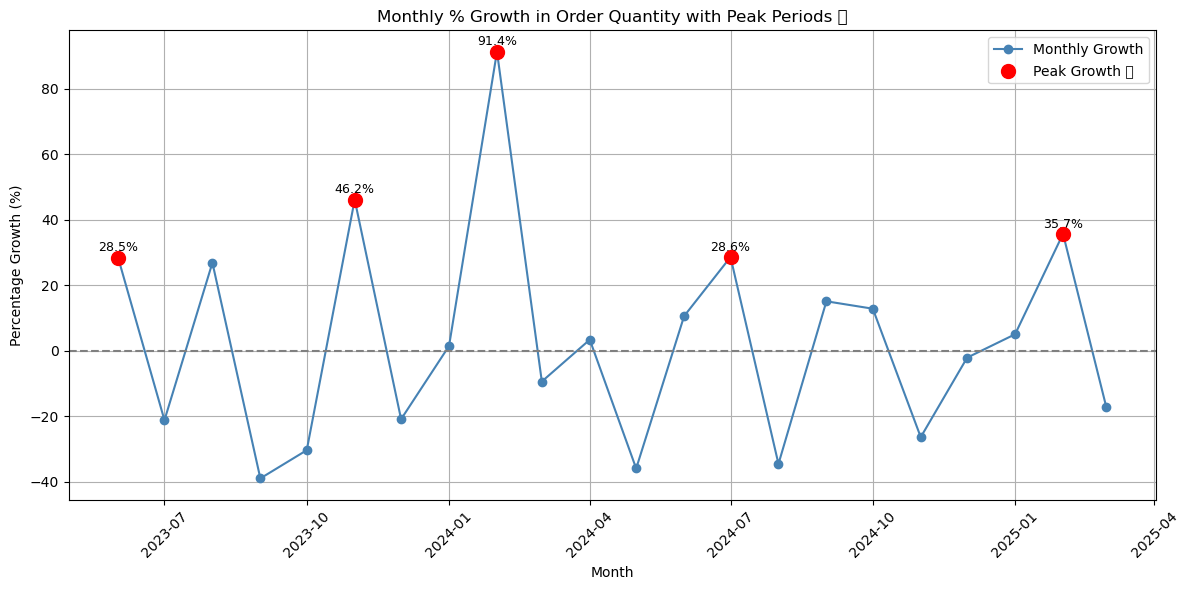

In [24]:
monthly_qty = df.groupby(pd.Grouper(key='ORDER DATE', freq='MS'))['Order Qty in MT'].sum().reset_index()

# 3. Calculate percentage growth month over month
monthly_qty['pct_growth'] = monthly_qty['Order Qty in MT'].pct_change() * 100

# 4. Identify peak periods (e.g., top 3 highest growth months)
top_growth = monthly_qty.nlargest(5, 'pct_growth')

# 5. Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_qty['ORDER DATE'], monthly_qty['pct_growth'], marker='o', linestyle='-', label='Monthly Growth', color='steelblue')

# Highlight peak periods with red markers
plt.scatter(top_growth['ORDER DATE'], top_growth['pct_growth'], color='red', s=100, label='Peak Growth 🚩', zorder=5)

# Annotate the points
for i, row in top_growth.iterrows():
    plt.text(row['ORDER DATE'], row['pct_growth'] + 1, f"{row['pct_growth']:.1f}%", ha='center', va='bottom', fontsize=9)

# Formatting
plt.title("Monthly % Growth in Order Quantity with Peak Periods 🚩")
plt.xlabel("Month")
plt.ylabel("Percentage Growth (%)")
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--')  # Zero line
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
#df['log_qty'] 

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7569 entries, 0 to 5007
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   PLANT                   7569 non-null   int64         
 1   ORDER DATE              7569 non-null   datetime64[ns]
 2   MONTH YEAR              7569 non-null   object        
 3   PO DATE                 4864 non-null   object        
 4   SALES DOC TYPE          7569 non-null   object        
 5   Ageing Days             7569 non-null   int64         
 6   CREATOR                 5008 non-null   object        
 7   SALES ORDER NO.         7569 non-null   int64         
 8   Sales Document Item     7569 non-null   int64         
 9   PO NO.                  5008 non-null   object        
 10  City Code Description   7527 non-null   object        
 11  SALES OFFICE            7507 non-null   object        
 12  SOLD. CUST. NAME        7332 non-null   object       

In [27]:
df.shape

(7569, 38)

In [28]:
x='auto'
if x=='auto':
    df= df[df['MATERIAL DESC.'].str.contains('AUT|PRP|SLT|TFF', case=False, na=False)]
elif x=='boiler':
    df= df[df['MATERIAL DESC.'].str.contains('BOT|AHT|COR', case=False, na=False)]
else:
    print("not in data")

In [29]:
#df.groupby(['Concat','MATERIAL DESC.'])['Order Qty in MT'].sum()

In [30]:
df.shape

(2808, 38)

In [31]:
material_map = df[['Concat', 'Month', 'Year', 'quarter', 'Material']].drop_duplicates()

In [32]:
material_map = df.groupby(['Concat', 'Month', 'Year', 'quarter'])['Material'].first().reset_index()

In [33]:
df1=df.groupby(['Concat','Month','Year','quarter','MATERIAL DESC.'])['Order Qty in MT'].sum().reset_index()

In [34]:
df1['log_qty'] = np.log1p(df1['Order Qty in MT'])

In [35]:
df1 = df1.merge(material_map, on=['Concat', 'Month', 'Year', 'quarter'], how='left')

In [36]:
#df1

In [37]:
df1.shape

(2125, 8)

In [38]:
df1['date'] = pd.to_datetime(df1[['Year', 'Month']].assign(day=1))

In [39]:
df1['date']

0      2025-02-01
1      2024-03-01
2      2024-05-01
3      2023-10-01
4      2024-01-01
          ...    
2120   2024-02-01
2121   2025-02-01
2122   2024-07-01
2123   2024-08-01
2124   2024-10-01
Name: date, Length: 2125, dtype: datetime64[ns]

In [40]:
# Ensure 'date' column is datetime
df1['date'] = pd.to_datetime(df1['date'])

# Extract 'year-month' to count unique months with orders
df1['year_month'] = df1['date'].dt.to_period('M')

# Group by category and material
active_pairs = (
    df1.groupby(['Concat', 'MATERIAL DESC.'])['year_month']
    .nunique()  # Count distinct months with orders
    .reset_index(name='active_months')
)

# Filter to those with at least 15 active months
active_pairs = active_pairs[active_pairs['active_months'] >= 6]

# Merge back to get full rows for only those (Concat, MATERIAL DESC.) pairs
df1 = df1.merge(active_pairs[['Concat', 'MATERIAL DESC.']], on=['Concat', 'MATERIAL DESC.'], how='inner')


In [41]:
df1 = df1.sort_values(['Concat', 'date']).reset_index(drop=True)

In [42]:
#df1.head(10)

In [43]:
df1.shape

(1569, 10)

def create_lag_rolling_features(group):
    group['lag_1'] = group['log_qty'].shift(1)
    group['lag_2'] = group['log_qty'].shift(2)
    group['rolling_2'] = group['log_qty'].rolling(2).mean()
    group['rolling_3'] = group['log_qty'].rolling(3).mean()
    return group.drop(columns='log_qty')

In [44]:
features_df = []

for (cat, material_desc), group in df1.groupby(['Concat', 'MATERIAL DESC.']):
    group = group.sort_values('date')
    material = group['Material'].iloc[0]
    base = group[['date', 'log_qty']].copy()
    g = group.set_index('date').resample('MS')[['log_qty']].sum().fillna(0)
    g['lag_1'] = g['log_qty'].shift(1)
    g['lag_2'] = g['log_qty'].shift(2)
    g['rolling_2'] = g['log_qty'].rolling(2).mean()
    g['rolling_3'] = g['log_qty'].rolling(3).mean()
    combined = base.set_index('date').join(g.drop(columns='log_qty')).reset_index()
    combined['Concat'] = cat
    combined['MATERIAL DESC.'] = material_desc
    combined['Material'] = material
    features_df.append(combined)
    #print(group)

In [45]:
data = pd.concat(features_df, ignore_index=True)
data['lag_2_missing'] = data['lag_2'].isna().astype(int)
data['lag_2'] = data.groupby('Concat')['lag_2'].transform(lambda x: x.fillna(x.mean()))

In [46]:
#data.head(10)

In [47]:
data.shape

(1569, 10)

In [48]:
#data.groupby(['Concat','MATERIAL DESC.'])['log_qty'].sum()

In [49]:
Q1 = data['log_qty'].quantile(0.25)
Q3 = data['log_qty'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['log_qty'] >= lower_bound) & (data['log_qty'] <= upper_bound)]

In [50]:
data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year

In [51]:
if x=='auto':
    peak_months = [2,6,10]  
    data['is_peak_month'] = data['month'].apply(lambda y: 1 if y in peak_months else 0)
elif x=='boiler':
    peak_months = [3,4,10]  
    data['is_peak_month'] = data['month'].apply(lambda y: 1 if y in peak_months else 0)

In [52]:
data = pd.get_dummies(data, columns=['Concat'])

In [53]:
#data

In [54]:
features = [col for col in data.columns if col.startswith("Concat_")] +  [ 'month', 'year', 'lag_1', 'lag_2', 'rolling_2', 'rolling_3','is_peak_month']
X = data[features]
y = data['log_qty']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [56]:
model = XGBRegressor(random_state=42, objective='reg:squarederror')

In [57]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [2,3],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "reg_alpha": [0.1, 0.5],
    "reg_lambda": [1, 2]
}

In [58]:
grid = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 0.8}


In [59]:
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [60]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.19
RMSE: 0.33
R² Score: 0.8865


Concat_10035.5: 0.0000
Concat_1004.55.65: 0.0000
Concat_101.63.415.3: 0.0016
Concat_101.63.416.4: 0.0000
Concat_103.894.574.65: 0.0000
Concat_12035.4: 0.0000
Concat_12045.4: 0.0192
Concat_151.55.6: 0.0002
Concat_181.55.145: 0.0000
Concat_19.051.25.53: 0.0000
Concat_19.051.46: 0.0000
Concat_19.051.636: 0.0000
Concat_19.051.66: 0.0000
Concat_19.052.37: 0.0000
Concat_19.0525.001: 0.0000
Concat_19.0525.841: 0.0000
Concat_19.0526: 0.0000
Concat_22.21.26: 0.0000
Concat_22.21.556.1: 0.0000
Concat_22.21.556.36: 0.0000
Concat_22.21.556.53: 0.0007
Concat_22.21.66: 0.0000
Concat_22.21.66.1: 0.0000
Concat_22.21.66.45: 0.0000
Concat_22.21.96.05: 0.0035
Concat_22.22.26.22: 0.0000
Concat_22.22.35.46: 0.0005
Concat_22.22.35.76: 0.0000
Concat_22.22.35.98: 0.0009
Concat_22.22.36.22: 0.0180
Concat_22.225.1: 0.0093
Concat_22.225.39: 0.0000
Concat_22.225.4: 0.0108
Concat_22.226: 0.0000
Concat_22.226.1: 0.0000
Concat_22.226.15: 0.0000
Concat_22.226.4: 0.0000
Concat_25.41.24.85: 0.0002
Concat_25.41.45.531: 0

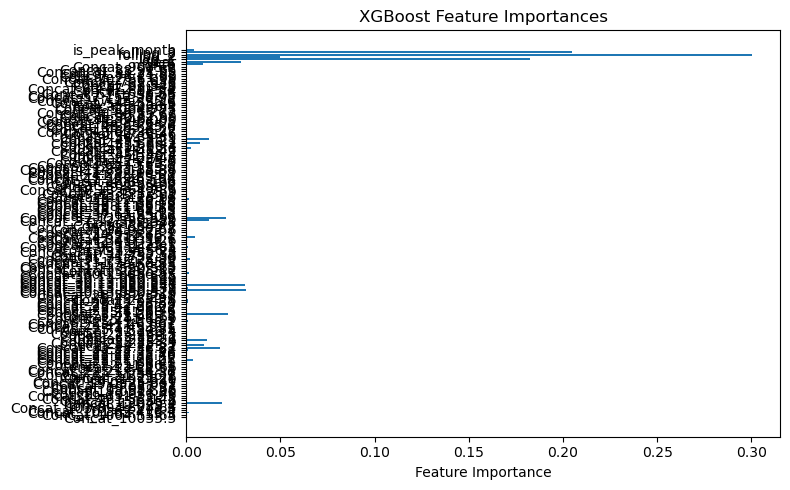

In [61]:
importance = best_model.feature_importances_
for name, score in zip(X.columns, importance):
    print(f"{name}: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.barh(X.columns, importance)
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [62]:
print("Train R2:", r2_score(y_train,best_model.predict(X_train)))
print("Test R2:", r2_score(y_test, best_model.predict(X_test)))

Train R2: 0.9335937341718348
Test R2: 0.8864977868355518


In [63]:
#data

In [64]:
y_test

1247    4.795791
1248    4.795791
1249    4.510860
1250    3.713572
1251    4.948760
          ...   
1564    3.044522
1565    1.945910
1566    2.772589
1567    2.397895
1568    2.397895
Name: log_qty, Length: 307, dtype: float64

In [65]:
y_pred

array([4.7571907, 4.804394 , 4.555618 , 4.1832595, 4.822534 , 3.8387558,
       5.021382 , 4.292781 , 5.05042  , 3.5826178, 2.4690273, 3.5451262,
       3.344126 , 3.1114397, 3.4598718, 3.1135879, 4.151747 , 3.1786313,
       3.7096548, 3.1559684, 4.321731 , 3.7314875, 4.4102015, 3.5826178,
       2.6696258, 3.8203933, 3.4186316, 1.880194 , 3.9627757, 4.2463613,
       4.149902 , 2.8315916, 3.4036162, 3.899818 , 2.80245  , 3.0022526,
       2.4155233, 2.4802127, 2.2673066, 2.7161953, 2.3574166, 2.7331243,
       2.883772 , 2.9146228, 2.665129 , 3.2268004, 2.5118477, 2.8292754,
       2.7928135, 3.0545115, 4.586896 , 3.7594826, 4.0357895, 4.2941923,
       3.188792 , 4.3905916, 2.4346457, 2.9462636, 4.263692 , 3.6347387,
       3.9388187, 4.0210657, 4.2826285, 2.520849 , 2.0573177, 4.0352736,
       2.4703538, 2.3723893, 4.1282086, 3.3053057, 2.520849 , 3.908463 ,
       1.9441003, 3.4037447, 3.670181 , 3.3076098, 3.053709 , 3.5139613,
       2.9472454, 3.3754036, 2.8174047, 3.047092 , 

In [66]:
h=np.exp(data['lag_1'])

In [67]:
f=np.exp(y_test)

In [68]:
g= np.exp(y_pred)

# 1 Month Prediction For All Material

In [69]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
data['Concat'] = data[[col for col in data.columns if col.startswith('Concat_')]].idxmax(axis=1).str.replace('Concat_', '')
recent_data = data.sort_values(['Concat', 'year', 'month'])
all_category_material_pairs = data[['Concat', 'MATERIAL DESC.']].drop_duplicates().values.tolist()

last_month = recent_data[['year', 'month']].drop_duplicates().sort_values(['year', 'month']).iloc[-1]
start_date = datetime(int(last_month['year']), int(last_month['month']), 1)

future_preds = []

working_data = recent_data.copy()


target_date = start_date + relativedelta(months=1)
month, year = target_date.month, target_date.year

filled_rows = []

for cat, mat_desc in all_category_material_pairs:
    group = working_data[(working_data['Concat'] == cat) & (working_data['MATERIAL DESC.'] == mat_desc)].copy()
    group = group.sort_values(['year', 'month'])

    if group.empty:
        continue

    latest = group.iloc[-1]

    lag_1 = latest['log_qty']
    lag_2 = group.iloc[-2]['log_qty'] if len(group) > 1 else lag_1
    rolling_2 = group['log_qty'].tail(2).mean()
    rolling_3 = group['log_qty'].tail(3).mean()

    row = {
        'Concat': cat,
        'MATERIAL DESC.': mat_desc,
        'month': month,
        'year': year,
        'lag_1': lag_1,
        'lag_2': lag_2,
        'rolling_2': rolling_2,
        'rolling_3': rolling_3,
        'is_peak_month': int(month in [2, 3, 10])
    }
    material = data[(data['Concat'] == cat) & (data['MATERIAL DESC.'] == mat_desc)]['Material'].mode()
    row['Material'] = material.iloc[0] if not material.empty else 'Unknown'
    
    for c in data.columns:
        if c.startswith('Concat_'):
            row[c] = 1 if c == f'Concat_{cat}' else 0

    for feat in features:
        if feat not in row:
            row[feat] = 0

    filled_rows.append(row)


    month_input = pd.DataFrame(filled_rows)[features]
    preds = best_model.predict(month_input)
    pred_df1 = pd.DataFrame(filled_rows)
    pred_df1['Predicted Order Qty'] = np.expm1(preds)
    pred_df1['month'] = month
    pred_df1['year'] = year
    #print(pred_df1[['MATERIAL DESC.','Material','Concat','month','year','is_peak_month','lag_1','lag_2','rolling_2','rolling_3','Predicted Order Qty']])

In [70]:
pred_df1

,Concat,MATERIAL DESC.,month,year,lag_1,lag_2,rolling_2,rolling_3,is_peak_month,Material,...,Concat_63.546,Concat_68.925,Concat_701.636,Concat_702.56.025,Concat_76.21.66,Concat_81.21.66,Concat_81.33.25.35,Concat_88.92.65,Concat_9035.2,Predicted Order Qty
0,10035.5,TUB-I-C-PRP-AD-PE-94.00X3.000X5.5000,4,2025,4.025352,4.454347,4.239849,4.270144,0,3502479,...,0,0,0,0,0,0,0,0,0,74.578979
1,1004.55.65,TUB-I-C-PRP-AD-PE-91.00X4.500X5.650,4,2025,2.397895,1.791759,2.094827,2.320748,0,3500418,...,0,0,0,0,0,0,0,0,0,6.649526
2,101.63.415.3,TUB-I-C-PRP-AD-PE-94.75X3.410X5.300,4,2025,4.836282,5.017280,4.926781,4.654812,0,3500191,...,0,0,0,0,0,0,0,0,0,133.807480
3,101.63.416.4,TUB-I-C-PRP-AD-PE-94.75X3.41X6.4 M-Sona,4,2025,3.258097,3.044522,3.151309,3.115714,0,3500314,...,0,0,0,0,0,0,0,0,0,20.454020
4,103.894.574.65,TUB-I-C-PRP-AD-FC-94.75X4.570X4.6500,4,2025,3.401197,0.916291,2.158744,2.583825,0,3502073,...,0,0,0,0,0,0,0,0,0,1.762616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,76.21.66,TUB-O-N-AUT-NR-FC-76.20X1.600X6.00-ERW 1,4,2025,4.043051,4.510860,4.276955,3.995966,0,3500226,...,0,0,0,0,1,0,0,0,0,79.699646
145,81.21.66,TUB-O-N-AUT-AW-PF-81.20X1.600X6.00-ERW 1,4,2025,3.044522,2.708050,2.876286,2.962689,0,3500229,...,0,0,0,0,0,1,0,0,0,17.065811
146,81.33.25.35,TUB-O-N-AUT-AW-FC-81.30X3.200X5.3500,4,2025,5.135798,3.931826,4.533812,4.419093,0,3502183,...,0,0,0,0,0,0,1,0,0,69.284454
147,88.92.65,TUB-O-N-AUT-AW-FC-88.90X2.600X5.0000,4,2025,3.044522,3.258097,3.151309,3.245535,0,3501564,...,0,0,0,0,0,0,0,1,0,26.322132


In [71]:
aprilpred= pred_df1[['MATERIAL DESC.','Material','Concat','month','year','is_peak_month','lag_1','lag_2','rolling_2','rolling_3','Predicted Order Qty']]

In [72]:
aprilpred

,MATERIAL DESC.,Material,Concat,month,year,is_peak_month,lag_1,lag_2,rolling_2,rolling_3,Predicted Order Qty
0,TUB-I-C-PRP-AD-PE-94.00X3.000X5.5000,3502479,10035.5,4,2025,0,4.025352,4.454347,4.239849,4.270144,74.578979
1,TUB-I-C-PRP-AD-PE-91.00X4.500X5.650,3500418,1004.55.65,4,2025,0,2.397895,1.791759,2.094827,2.320748,6.649526
2,TUB-I-C-PRP-AD-PE-94.75X3.410X5.300,3500191,101.63.415.3,4,2025,0,4.836282,5.017280,4.926781,4.654812,133.807480
3,TUB-I-C-PRP-AD-PE-94.75X3.41X6.4 M-Sona,3500314,101.63.416.4,4,2025,0,3.258097,3.044522,3.151309,3.115714,20.454020
4,TUB-I-C-PRP-AD-FC-94.75X4.570X4.6500,3502073,103.894.574.65,4,2025,0,3.401197,0.916291,2.158744,2.583825,1.762616
...,...,...,...,...,...,...,...,...,...,...,...
144,TUB-O-N-AUT-NR-FC-76.20X1.600X6.00-ERW 1,3500226,76.21.66,4,2025,0,4.043051,4.510860,4.276955,3.995966,79.699646
145,TUB-O-N-AUT-AW-PF-81.20X1.600X6.00-ERW 1,3500229,81.21.66,4,2025,0,3.044522,2.708050,2.876286,2.962689,17.065811
146,TUB-O-N-AUT-AW-FC-81.30X3.200X5.3500,3502183,81.33.25.35,4,2025,0,5.135798,3.931826,4.533812,4.419093,69.284454
147,TUB-O-N-AUT-AW-FC-88.90X2.600X5.0000,3501564,88.92.65,4,2025,0,3.044522,3.258097,3.151309,3.245535,26.322132


In [73]:
aprilpred.to_excel("AprilPrediction.xlsx", index=False)

In [74]:
aprilpred.to_csv("Aprilprediction.csv", index=False, encoding='utf-8')

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(X_test.index, y_test, label="Actual", marker='o')
plt.plot(X_test.index, y_pred, label="Predicted", marker='x')
plt.title("Actual vs Predicted Order Quantity")
plt.xlabel("Test Sample Index")
plt.ylabel("Order Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# For Comparison

In [ ]:
test_indices = X_test.index
material_desc = data.loc[test_indices, 'MATERIAL DESC.']
material = data.loc[test_indices, 'Material']
category_cols = [col for col in data.columns if col.startswith("Concat_")]
category_data_test = data.loc[test_indices, category_cols]
category_names = category_data_test.idxmax(axis=1).str.replace('Concat_', '')
month_col = data.loc[test_indices, 'month']
lag_1 = data.loc[test_indices, 'lag_1']
lag_2 = data.loc[test_indices, 'lag_2']
rolling_2 = data.loc[test_indices, 'rolling_2']
rolling_3 = data.loc[test_indices, 'rolling_3']
year_col = data.loc[test_indices, 'year']
results_df = pd.DataFrame({
    'category': category_names,
    'MATERIAL DESC.': material_desc.values,
    'Material': material.values,
    'month': month_col.values,
    'lag_1': lag_1.values,
    'lag_2': lag_2.values,
    'rolling_2': rolling_2.values,
    'rolling_3': rolling_3.values,
    'year': year_col.values,
    'y_test': f.values,
    'y_pred': g
})

In [ ]:
print(results_df)

In [ ]:
results_df.to_csv("model_output.csv", index=False, encoding='utf-8')

In [ ]:
results_df.to_excel("output.xlsx", index=False)

# FOR 3 MONTHS

In [ ]:
from datetime import datetime
from dateutil.relativedelta import relativedelta

data['Concat'] = data[[col for col in data.columns if col.startswith('Concat_')]].idxmax(axis=1).str.replace('Concat_', '')
recent_data = data.sort_values(['Concat', 'year', 'month'])
all_category_material_pairs = data[['Concat', 'MATERIAL DESC.']].drop_duplicates().values.tolist()

last_month = recent_data[['year', 'month']].drop_duplicates().sort_values(['year', 'month']).iloc[-1]
start_date = datetime(int(last_month['year']), int(last_month['month']), 1)

future_preds = []

working_data = recent_data.copy()

for i in range(1, 4): 
    target_date = start_date + relativedelta(months=i)
    month, year = target_date.month, target_date.year

    filled_rows = []

    for cat, mat_desc in all_category_material_pairs:
        group = working_data[(working_data['Concat'] == cat) & (working_data['MATERIAL DESC.'] == mat_desc)].copy()
        group = group.sort_values(['year', 'month'])

        if group.empty:
            continue

        latest = group.iloc[-1]

        lag_1 = latest['log_qty']
        lag_2 = group.iloc[-2]['log_qty'] if len(group) > 1 else lag_1
        rolling_2 = group['log_qty'].tail(2).mean()
        rolling_3 = group['log_qty'].tail(3).mean()

        row = {
            'Concat': cat,
            'MATERIAL DESC.': mat_desc,
            'month': month,
            'year': year,
            'lag_1': lag_1,
            'lag_2': lag_2,
            'rolling_2': rolling_2,
            'rolling_3': rolling_3,
            'is_peak_month': int(month in [2, 3, 10])
        }
        material = data[(data['Concat'] == cat) & (data['MATERIAL DESC.'] == mat_desc)]['Material'].mode()
        row['Material'] = material.iloc[0] if not material.empty else 'Unknown'
        for c in data.columns:
            if c.startswith('Concat_'):
                row[c] = 1 if c == f'Concat_{cat}' else 0

        for feat in features:
            if feat not in row:
                row[feat] = 0

        filled_rows.append(row)

    month_input = pd.DataFrame(filled_rows)[features]
    preds = best_model.predict(month_input)
    pred_df = pd.DataFrame(filled_rows)
    pred_df['Predicted Order Qty'] = np.expm1(preds)
    pred_df['month'] = month
    pred_df['year'] = year

 
    future_preds.append(pred_df)

    temp_append = pred_df[['Concat', 'MATERIAL DESC.','Material', 'month', 'year', 'Predicted Order Qty']].copy()
    temp_append['log_qty'] = np.log1p(temp_append['Predicted Order Qty'])
    working_data = pd.concat([working_data, temp_append], ignore_index=True)
    
final_future_preds = pd.concat(future_preds, ignore_index=True)

total_3month_qty = final_future_preds.groupby(['Concat', 'MATERIAL DESC.'])['Predicted Order Qty'].sum().reset_index()

In [ ]:
last_month

In [ ]:
#total_3month_qty 

In [ ]:
#future_preds

In [ ]:
final_future_preds= final_future_preds[['MATERIAL DESC.','Material','Concat','month','year','is_peak_month','lag_1','lag_2','rolling_2','rolling_3','Predicted Order Qty']]

In [ ]:
final_future_preds.to_csv("3months.csv", index=False, encoding='utf-8')

In [ ]:
final_future_preds.to_excel("3months.xlsx", index=False)